This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [3]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.26.0 which is incompatible.


In [4]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [5]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Fundamentals of machine learning

### Generalization: The goal of machine learning

#### Underfitting and overfitting

##### Noisy training data

##### Ambiguous features

##### Rare features and spurious correlations

In [6]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8651 - loss: 0.4538 - val_accuracy: 0.9232 - val_loss: 0.2641
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9320 - loss: 0.2306 - val_accuracy: 0.9412 - val_loss: 0.1987
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9530 - loss: 0.1558 - val_accuracy: 0.9473 - val_loss: 0.1750
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9681 - loss: 0.1109 - val_accuracy: 0.9552 - val_loss: 0.1526
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9758 - loss: 0.0828 - val_accuracy: 0.9585 - val_loss: 0.1407
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9847 - loss: 0.0547 - val_accuracy: 0.9627 - val_loss: 0.1319
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9883 - loss: 0.0426 - val_accuracy: 0.9640 - val_loss: 0.1271
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9925 - loss: 0.0292 - val_accuracy: 0.

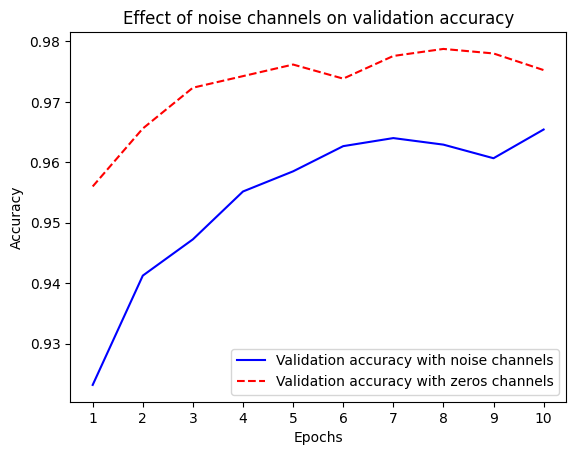

In [8]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)
plt.plot(
    epochs,
    val_acc_zeros,
    "r--",
    label="Validation accuracy with zeros channels",
)
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### The nature of generalization in deep learning

In [9]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1064 - loss: 2.3152 - val_accuracy: 0.1063 - val_loss: 2.3064
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1192 - loss: 2.2989 - val_accuracy: 0.1040 - val_loss: 2.3110
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1267 - loss: 2.2898 - val_accuracy: 0.1047 - val_loss: 2.3194
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1400 - loss: 2.2773 - val_accuracy: 0.1028 - val_loss: 2.3310
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1545 - loss: 2.2611 - val_accuracy: 0.1062 - val_loss: 2.3353
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1684 - loss: 2.2416 - val_accuracy: 0.1034 - val_loss: 2.3505
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1857 - loss: 2.2172 - val_accuracy: 0.1013 - val_loss: 2.3691
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1994 - loss: 2.1909 - val_accu

##### The manifold hypothesis

##### Interpolation as a source of generalization

##### Why deep learning works

##### Training data is paramount

### Evaluating machine-learning models

#### Training, validation, and test sets

##### Simple hold-out validation

##### K-fold validation

##### Iterated K-fold validation with shuffling

#### Beating a common-sense baseline

#### Things to keep in mind about model evaluation

### Improving model fit

#### Tuning key gradient descent parameters

In [10]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1021 - loss: 14.4396 - val_accuracy: 0.1035 - val_loss: 14.4499
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1019 - loss: 14.4764 - val_accuracy: 0.1035 - val_loss: 14.4499
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1019 - loss: 14.4764 - val_accuracy: 0.1035 - val_loss: 14.4499
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1019 - loss: 14.4764 - val_accuracy: 0.1035 - val_loss: 14.4499
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1019 - loss: 14.4764 - val_accuracy: 0.1035 - val_loss: 14.4499
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1019 - loss: 14.4764 - val_accuracy: 0.1035 - val_loss: 14.4499
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1019 - loss: 14.4764 - val_accuracy: 0.1035 - val_loss: 14.4499
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1019 - loss: 14.4764 - v

In [11]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9038 - loss: 0.4796 - val_accuracy: 0.9621 - val_loss: 0.1340
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9655 - loss: 0.1258 - val_accuracy: 0.9646 - val_loss: 0.1331
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9737 - loss: 0.0997 - val_accuracy: 0.9761 - val_loss: 0.1125
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9793 - loss: 0.0823 - val_accuracy: 0.9630 - val_loss: 0.1852
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9825 - loss: 0.0746 - val_accuracy: 0.9722 - val_loss: 0.1634
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9854 - loss: 0.0638 - val_accuracy: 0.9722 - val_loss: 0.1608
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9878 - loss: 0.0591 - val_accuracy: 0.9743 - val_loss: 0.1737
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9872 - loss: 0.0623 - val_accuracy: 0.

#### Using better architecture priors

#### Increasing model capacity

In [12]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_small_model = model.fit(
    train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8299 - loss: 0.6792 - val_accuracy: 0.9009 - val_loss: 0.3616
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9029 - loss: 0.3531 - val_accuracy: 0.9151 - val_loss: 0.3108
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9113 - loss: 0.3179 - val_accuracy: 0.9193 - val_loss: 0.2936
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9160 - loss: 0.3016 - val_accuracy: 0.9216 - val_loss: 0.2852
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9187 - loss: 0.2922 - val_accuracy: 0.9230 - val_loss: 0.2795
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9204 - loss: 0.2855 - val_accuracy: 0.9223 - val_loss: 0.2791
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9210 - loss: 0.2805 - val_accuracy: 0.9252 - val_loss: 0.2715
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9229 - loss: 0.2765 - val_accuracy: 0.

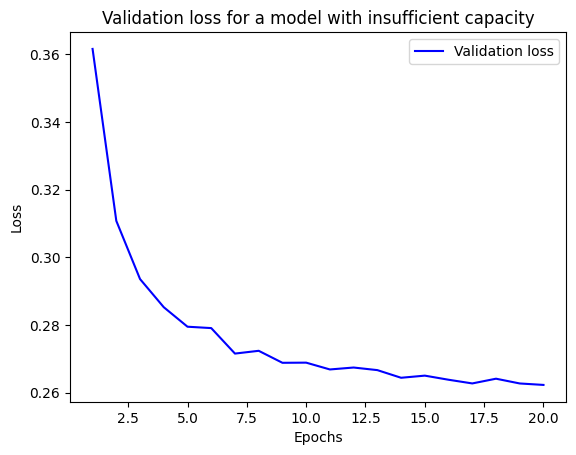

In [13]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9011 - loss: 0.3424 - val_accuracy: 0.9503 - val_loss: 0.1667
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9565 - loss: 0.1437 - val_accuracy: 0.9610 - val_loss: 0.1326
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9693 - loss: 0.0995 - val_accuracy: 0.9682 - val_loss: 0.1100
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9777 - loss: 0.0741 - val_accuracy: 0.9703 - val_loss: 0.0946
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9817 - loss: 0.0581 - val_accuracy: 0.9711 - val_loss: 0.0976
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9853 - loss: 0.0475 - val_accuracy: 0.9740 - val_loss: 0.0872
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9884 - loss: 0.0374 - val_accuracy: 0.9714 - val_loss: 0.1007
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9899 - loss: 0.0305 - val_accuracy: 0.

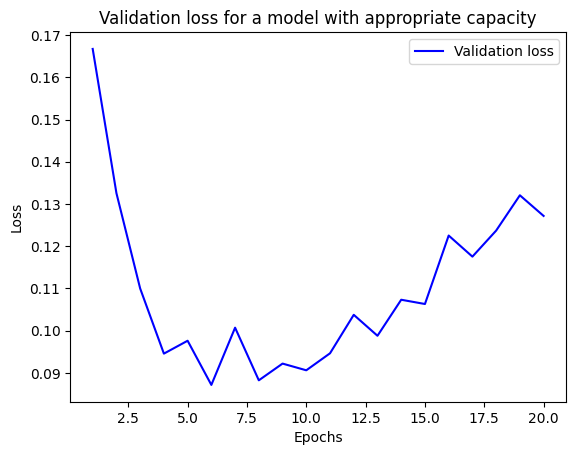

In [15]:
val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with appropriate capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [16]:
model = keras.Sequential(
    [
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_very_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9262 - loss: 0.2570 - val_accuracy: 0.9661 - val_loss: 0.1186
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9692 - loss: 0.1151 - val_accuracy: 0.9678 - val_loss: 0.1308
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9784 - loss: 0.0849 - val_accuracy: 0.9737 - val_loss: 0.1180
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9834 - loss: 0.0672 - val_accuracy: 0.9697 - val_loss: 0.1592
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9859 - loss: 0.0606 - val_accuracy: 0.9722 - val_loss: 0.1398
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9895 - loss: 0.0464 - val_accuracy: 0.9754 - val_loss: 0.1371
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9911 - loss: 0.0399 - val_accuracy: 0.9728 - val_loss: 0.1564
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9929 - loss: 0.0319 - 

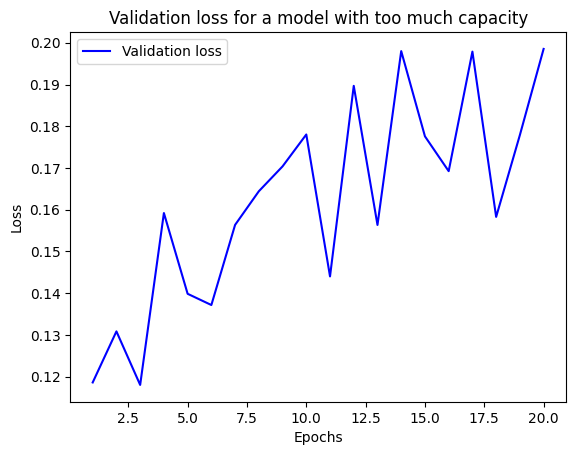

In [17]:
val_loss = history_very_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with too much capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Improving generalization

#### Dataset curation

#### Feature engineering

#### Using early stopping

#### Regularizing your model

##### Reducing the network's size

In [18]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_original = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.7699 - loss: 0.5332 - val_accuracy: 0.8685 - val_loss: 0.4057
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8961 - loss: 0.3313 - val_accuracy: 0.8805 - val_loss: 0.3296
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9209 - loss: 0.2482 - val_accuracy: 0.8528 - val_loss: 0.3493
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9330 - loss: 0.2054 - val_accuracy: 0.8896 - val_loss: 0.2803
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9481 - loss: 0.1679 - val_accuracy: 0.8884 - val_loss: 0.2822
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9547 - loss: 0.1433 - val_accuracy: 0.8863 - val_loss: 0.2893
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9637 - loss: 0.1218 - val_accuracy: 0.8855 - val_loss: 0.2975
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accurac

In [19]:
model = keras.Sequential(
    [
        layers.Dense(4, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_smaller_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6433 - loss: 0.6329 - val_accuracy: 0.6922 - val_loss: 0.5760
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7799 - loss: 0.5331 - val_accuracy: 0.8120 - val_loss: 0.5233
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8491 - loss: 0.4812 - val_accuracy: 0.8439 - val_loss: 0.4951
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8853 - loss: 0.4457 - val_accuracy: 0.8108 - val_loss: 0.4928
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9067 - loss: 0.4190 - val_accuracy: 0.8429 - val_loss: 0.4756
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9243 - loss: 0.3964 - val_accuracy: 0.8758 - val_loss: 0.4585
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9373 - loss: 0.3773 - val_accuracy: 0.8555 - val_loss: 0.4696
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9473 - loss: 0.3594 - val_accuracy: 0.8580 - v

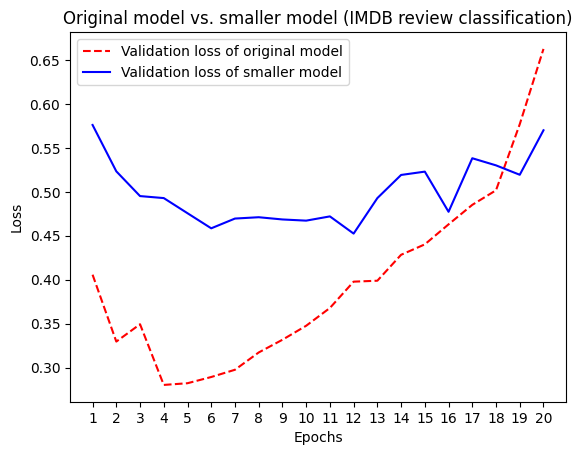

In [20]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.title("Original model vs. smaller model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [21]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_larger_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7217 - loss: 0.5678 - val_accuracy: 0.7469 - val_loss: 0.4976
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8700 - loss: 0.3222 - val_accuracy: 0.8863 - val_loss: 0.2754
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9005 - loss: 0.2474 - val_accuracy: 0.8866 - val_loss: 0.2731
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9263 - loss: 0.1928 - val_accuracy: 0.8768 - val_loss: 0.3067
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9437 - loss: 0.1495 - val_accuracy: 0.8802 - val_loss: 0.2956
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9673 - loss: 0.0994 - val_accuracy: 0.8847 - val_loss: 0.3473
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9720 - loss: 0.0900 - val_accuracy: 0.8847 - val_loss: 0.3458
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9770 - loss: 0.0832 - val_accuracy: 0.8874 - v

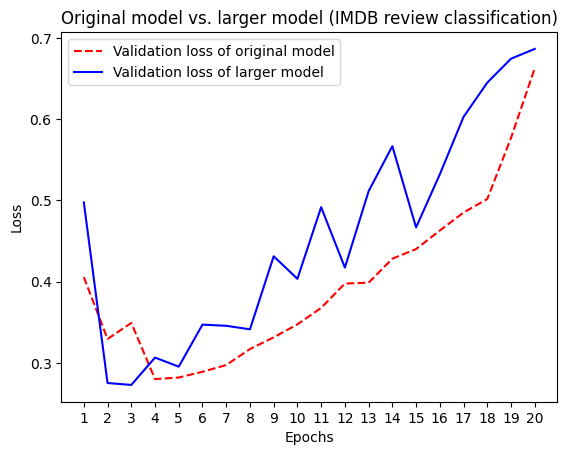

In [22]:
original_val_loss = history_original.history["val_loss"]
larger_model_val_loss = history_larger_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    larger_model_val_loss,
    "b-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

##### Adding weight regularization

In [23]:
from keras.regularizers import l2

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7334 - loss: 0.6579 - val_accuracy: 0.8483 - val_loss: 0.5251
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8799 - loss: 0.4443 - val_accuracy: 0.8778 - val_loss: 0.4158
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9074 - loss: 0.3561 - val_accuracy: 0.8841 - val_loss: 0.3770
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9211 - loss: 0.3125 - val_accuracy: 0.8715 - val_loss: 0.3893
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9273 - loss: 0.2923 - val_accuracy: 0.8848 - val_loss: 0.3608
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9345 - loss: 0.2717 - val_accuracy: 0.8791 - val_loss: 0.3728
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9391 - loss: 0.2586 - val_accuracy: 0.8816 - val_loss: 0.3630
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9433 - loss: 0.2503 - val_accuracy: 0.8831 - v

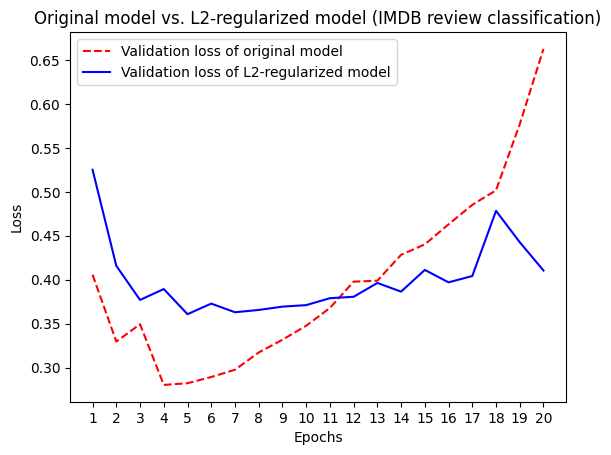

In [24]:
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of L2-regularized model",
)
plt.title(
    "Original model vs. L2-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [25]:
from keras import regularizers

regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

##### Adding dropout

In [26]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6319 - loss: 0.6349 - val_accuracy: 0.8381 - val_loss: 0.5210
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7727 - loss: 0.5069 - val_accuracy: 0.8681 - val_loss: 0.4088
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8288 - loss: 0.4234 - val_accuracy: 0.8744 - val_loss: 0.3537
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8634 - loss: 0.3670 - val_accuracy: 0.8843 - val_loss: 0.3130
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8914 - loss: 0.3211 - val_accuracy: 0.8878 - val_loss: 0.2895
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9075 - loss: 0.2831 - val_accuracy: 0.8892 - val_loss: 0.2787
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9235 - loss: 0.2503 - val_accuracy: 0.8857 - val_loss: 0.2798
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9283 - loss: 0.2268 - val_accuracy: 0.8916 - v

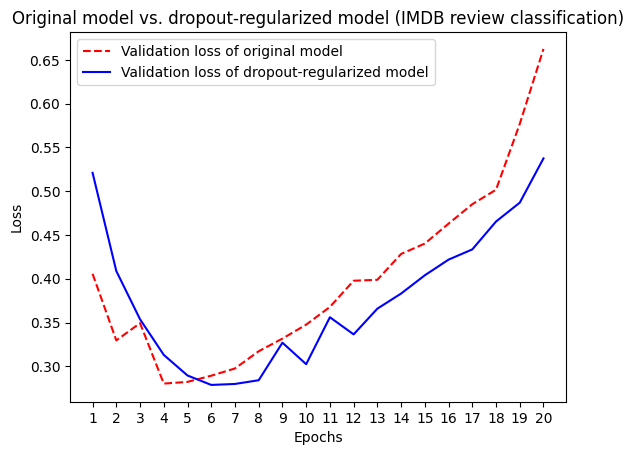

In [27]:
original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)
plt.title(
    "Original model vs. dropout-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

ORIGINAL MNIST DATASET
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)

NEW MIXED DATASET
New training images shape: (29071, 28, 28)
New training labels shape: (29071,)
New test images shape: (4814, 28, 28)
New test labels shape: (4814,)

Training images per label:
  Label 0: 5923 images
  Label 1: 5958 images
  Label 2: 5421 images
  Label 3: 5918 images
  Label 4: 5851 images

Test images per label:
  Label 0: 980 images
  Label 1: 1010 images
  Label 2: 892 images
  Label 3: 958 images
  Label 4: 974 images

SAMPLE IMAGES FROM NEW DATASET


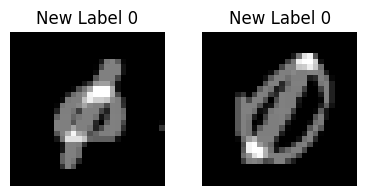

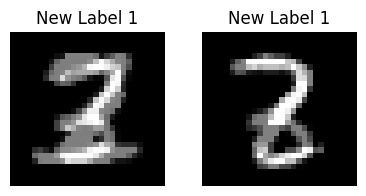

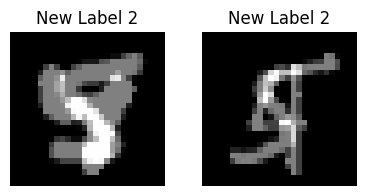

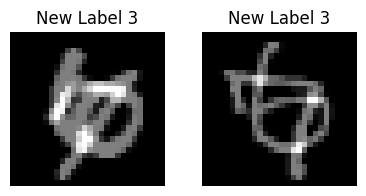

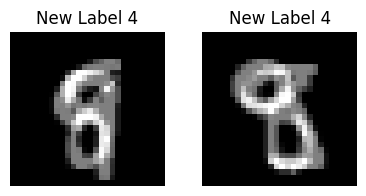

In [28]:
# Load MNIST
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Verify original MNIST sizes
print("="*50)
print("ORIGINAL MNIST DATASET")
print("="*50)
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
print()

def create_mixed_dataset(images, labels, label_a, label_b):
    #overlaps 0 or 1 with numbers in the dataset
    imgs_a = images[labels == label_a]
    imgs_b = images[labels == label_b]

    n_pairs = min(len(imgs_a), len(imgs_b))

    # Shuffle and take pairs
    np.random.shuffle(imgs_a)
    np.random.shuffle(imgs_b)

    # Average the pairs
    mixed = (imgs_a[:n_pairs].astype('float32') +
             imgs_b[:n_pairs].astype('float32')) / 2

    return mixed

# Create new training dataset
new_train_images = []
new_train_labels = []

for new_label, (old_a, old_b) in enumerate([(0,1), (2,3), (4,5), (6,7), (8,9)]):
    mixed = create_mixed_dataset(train_images, train_labels, old_a, old_b)
    new_train_images.append(mixed)
    new_train_labels.append(np.full(len(mixed), new_label))

new_train_images = np.concatenate(new_train_images)
new_train_labels = np.concatenate(new_train_labels)


new_test_images = []
new_test_labels = []

for new_label, (old_a, old_b) in enumerate([(0,1), (2,3), (4,5), (6,7), (8,9)]):
    mixed = create_mixed_dataset(test_images, test_labels, old_a, old_b)
    new_test_images.append(mixed)
    new_test_labels.append(np.full(len(mixed), new_label))

new_test_images = np.concatenate(new_test_images)
new_test_labels = np.concatenate(new_test_labels)

# Verify new mixed dataset sizes (should be exact same as the start)
print("="*50)
print("NEW MIXED DATASET")
print("="*50)
print(f"New training images shape: {new_train_images.shape}")
print(f"New training labels shape: {new_train_labels.shape}")
print(f"New test images shape: {new_test_images.shape}")
print(f"New test labels shape: {new_test_labels.shape}")
print()

# Count images per label
print("Training images per label:")
for label in range(5):
    count = np.sum(new_train_labels == label)
    print(f"  Label {label}: {count} images")
print()

print("Test images per label:")
for label in range(5):
    count = np.sum(new_test_labels == label)
    print(f"  Label {label}: {count} images")
print()

# Display 2 random images per label
print("="*50)
print("SAMPLE IMAGES FROM NEW DATASET")
print("="*50)

for label in range(5):
    indices = np.where(new_train_labels == label)[0]
    sample_indices = np.random.choice(indices, 2, replace=False)

    plt.figure(figsize=(4, 2))
    for i, idx in enumerate(sample_indices):
        plt.subplot(1, 2, i+1)
        plt.imshow(new_train_images[idx], cmap='gray')
        plt.title(f'New Label {label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


Epoch 1/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7544 - loss: 0.6666 - val_accuracy: 0.9496 - val_loss: 0.1742
Epoch 2/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9092 - loss: 0.2882 - val_accuracy: 0.9601 - val_loss: 0.1262
Epoch 3/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9330 - loss: 0.2168 - val_accuracy: 0.9608 - val_loss: 0.1201
Epoch 4/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9451 - loss: 0.1850 - val_accuracy: 0.9658 - val_loss: 0.1094
Epoch 5/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9503 - loss: 0.1665 - val_accuracy: 0.9673 - val_loss: 0.1010
Epoch 6/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9561 - loss: 0.1479 - val_accuracy: 0.9699 - val_loss: 0.0936
Epoch 7/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9585 - loss: 0.1408 - val_accuracy: 0.9718 - val_loss: 0.0945
Epoch 8/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9614 - loss: 0.1281 - val_accuracy: 0

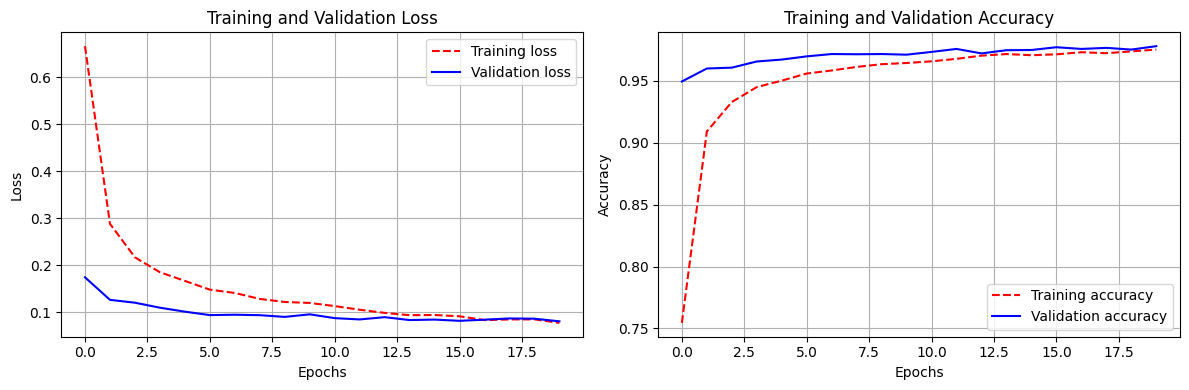

151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9782 - loss: 0.0731

Final Test Results:
Test Loss: 0.0731
Test Accuracy: 0.9782 (97.82%)

ANALYSIS:
✗ No underfitting observed
✗ No significant overfitting observed

✓ Used L2 regularization (0.001) on Dense layers
✓ Used Dropout (0.3) between layers

These help prevent overfitting by:
- L2: Penalizes large weights
- Dropout: Randomly drops connections during training


In [31]:
# Prepare data (assuming you have new_train_images, new_train_labels, etc. from Problem 4)
# Reshape and normalize
x_train = new_train_images.reshape((len(new_train_images), 28 * 28)).astype('float32') / 255
x_test = new_test_images.reshape((len(new_test_images), 28 * 28)).astype('float32') / 255
y_train = new_train_labels
y_test = new_test_labels

# Split training into train and validation
from sklearn.model_selection import train_test_split
x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

# Build model
model = keras.Sequential([
    layers.Dense(128, activation="relu", kernel_regularizer=l2(0.001)),  # Try: 64, 128, 256, 512
    layers.Dropout(0.3),  # Try: 0.2, 0.3, 0.5
    layers.Dense(64, activation="relu", kernel_regularizer=l2(0.001)),   # Try: 32, 64, 128
    layers.Dropout(0.3),  # Try: 0.2, 0.3, 0.5
    layers.Dense(5, activation="softmax"),  # 5 classes - don't change this
])

# Compile
model.compile(
    optimizer="adam",  # Try: "adam", "rmsprop", keras.optimizers.Adam(learning_rate=0.0001)
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    x_train_split,
    y_train_split,
    epochs=20,  # Try: 10, 20, 30
    batch_size=128,  # Try: 64, 128, 256
    validation_data=(x_val, y_val)
)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'r--', label='Training loss')
plt.plot(history.history['val_loss'], 'b-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'r--', label='Training accuracy')
plt.plot(history.history['val_accuracy'], 'b-', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Test performance
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"\nFinal Test Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

